# DataDriven_Soccer_Scouting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models


import warnings
warnings.filterwarnings("ignore")

import time

start_time = time.time()

## Introduction and EDA

In [2]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Touches_Att 3rd,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,DF,26,1997,17,13,...,238,28,214,55,813,367,813,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",22,2001,25,20,...,715,162,57,6,978,216,979,178.0,65.0,Left
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,GK,28,1995,38,38,...,0,0,1388,880,1480,92,1480,183.0,75.0,Right
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,25,1999,35,33,...,733,81,325,82,1948,909,1948,185.0,80.0,Right
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,DF,26,1997,28,28,...,225,40,672,189,1873,985,1873,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [3]:
#Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3396 
- columns: 117


In [4]:
# select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,pos,Preferred foot
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",Left
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,Right
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,"FW,MF",Right
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,DF,Left
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,DF,Right


In [5]:
# Convert 'Preferred foot' to binary: 1 for 'Right', 0 for 'Left'
df['right_foot'] = df['Preferred foot'].map({'Right': 1, 'Left': 0})
df.drop('Preferred foot', axis=1, inplace=True)

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matrix 'X' shape: 3396 players x 109 statistics


## Similarity Search

### PCA

In [6]:
# ==========================================
# 1. ADDESTRAMENTO DELLA PCA (Dimensionality Reduction)
# ==========================================
print("--- Addestramento Modello Baseline: PCA ---")

# Scegliamo 10 componenti principali (di solito bastano per trattenere l'80%+ dell'informazione)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Controlliamo quanta "informazione" (varianza) abbiamo conservato comprimendo i dati
varianza_totale = sum(pca.explained_variance_ratio_) * 100
print(f"Varianza spiegata con 10 componenti: {varianza_totale:.2f}%")

# ==========================================
# 2. CREAZIONE DELLO "SPAZIO LATENTE"
# ==========================================
# Creiamo un DataFrame con le nuove 10 coordinate matematiche
colonne_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=colonne_pca)

# Uniamo queste coordinate alle informazioni di testo (nomi, squadre, ruoli) salvate prima
# Reset dell'indice per essere sicuri che si allineino perfettamente
df_info_reset = df_info.reset_index(drop=True)
df_latent = pd.concat([df_info_reset, df_pca], axis=1)

# ==========================================
# 3. MOTORE DI RICERCA (Similarity Search)
# ==========================================
def trova_simili_pca(nome_giocatore, df_latente, top_n=5):
    """
    Trova i giocatori più simili usando la Cosine Similarity sulle componenti PCA.
    """
    # Cerca il giocatore ignorando maiuscole/minuscole
    giocatore_idx = df_latente[df_latente['player'].str.lower() == nome_giocatore.lower()].index
    
    if len(giocatore_idx) == 0:
        return f"Errore: Giocatore '{nome_giocatore}' non trovato nel dataset. Prova a controllare come è scritto."
    
    # Se ce n'è più di uno (es. omonimi o stagioni diverse), prendiamo il primo
    idx = giocatore_idx[0] 
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    print(f"\nRicerca cloni per: {giocatore_reale} ({squadra_reale})")
    
    # Isoliamo il "DNA" (vettore a 10 dimensioni) del nostro giocatore target
    giocatore_vettore = df_latente.loc[idx, colonne_pca].values.reshape(1, -1)
    
    # Estraiamo il "DNA" di tutti i giocatori del dataset
    tutti_i_vettori = df_latente[colonne_pca].values
    
    # Calcoliamo la Similarità Coseno (1.0 = identico, 0.0 = totalmente diverso)
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]
    
    # Aggiungiamo il punteggio al dataframe
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita
    
    # Ordiniamo dal più simile al meno simile
    # Saltiamo il primo risultato (che sarà il giocatore stesso con score 1.0)
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).iloc[1:top_n+1]
    
    # Formattiamo lo score in percentuale per renderlo più leggibile
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'
    # Mostriamo solo le colonne che ci interessano
    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

# ==========================================
# 4. TEST DELLO SCOUTING
# ==========================================
target = "Kevin De Bruyne" 
risultati = trova_simili_pca(target, df_latent, top_n=5)
display(risultati)

--- Addestramento Modello Baseline: PCA ---
Varianza spiegata con 10 componenti: 82.22%

Ricerca cloni per: Kevin De Bruyne (Manchester City)


,player,age,team,pos,league,season,Match %
1994,Jonas Hofmann,31,Leverkusen,MF,GER-Bundesliga,2023 - 2024,94.6%
1365,Kevin De Bruyne,32,Manchester City,MF,ENG-Premier League,2023 - 2024,93.7%
732,Julian Brandt,28,Dortmund,MF,GER-Bundesliga,2024 - 2025,91.2%
3324,Piotr Zieliński,28,Napoli,MF,ITA-Serie A,2022 - 2023,90.9%
1041,Federico Dimarco,26,Inter,"DF,FW",ITA-Serie A,2024 - 2025,89.5%


### Deep Autoencoder

#### Mix ReLU

In [7]:
"""print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)"""

'print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. COSTRUZIONE DELL\'ARCHITETTURA \n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (Compressione con attivazione ReLU + tanh per un po\' di non linearità in più)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Ricostruzione)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Output finale (Torna al numero di colonne originali, lineare)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. C

#### Mix Tanh

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2143
Epoch 2/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1468
Epoch 3/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1267
Epoch 4/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1158
Epoch 5/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1089
Epoch 6/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1025
Epoch 7/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0975
Epoch 8/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0929
Epoch 9/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0901
Epoch 10/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0870
Epoch 11/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0846
Epoch 12/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0830
Epoch 13/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0807
Epoch 14/100
213/213 ━━━━━━━━

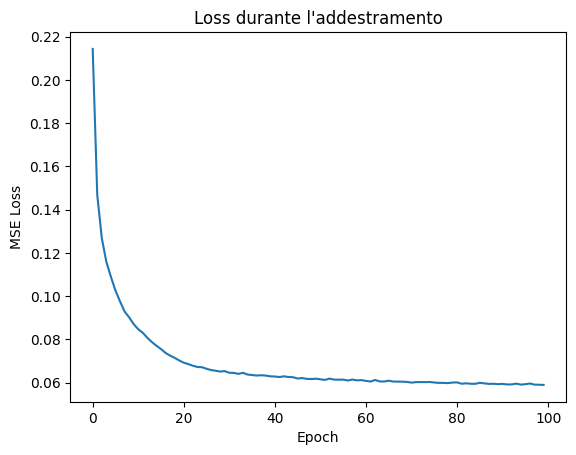


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [8]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)

#### Mix Tanh Deeper

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.2034
Epoch 2/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1545
Epoch 3/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1421
Epoch 4/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1368
Epoch 5/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1319
Epoch 6/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1287
Epoch 7/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1240
Epoch 8/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1204
Epoch 9/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1181
Epoch 10/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1163
Epoch 11/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1138
Epoch 12/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1134
Epoch 13/300
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1119
Epoch 14/300
213/213 ━━━━━

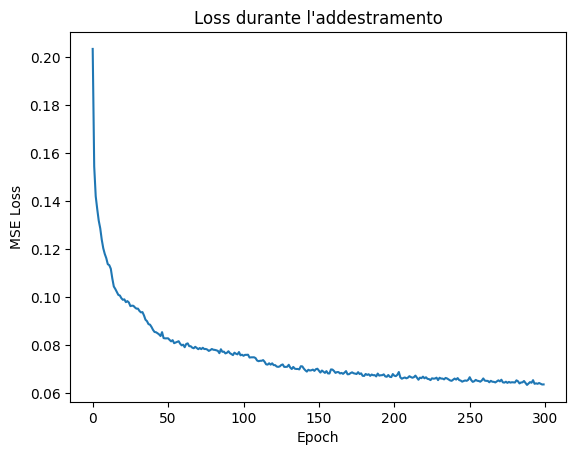


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [9]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(56, activation='tanh')(encoded)
encoded = layers.Dense(48, activation='tanh')(encoded)
encoded = layers.Dense(40, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)
encoded = layers.Dense(24, activation='tanh')(encoded)
encoded = layers.Dense(16, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(16, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(24, activation='tanh')(decoded)
decoded = layers.Dense(32, activation='tanh')(decoded)
decoded = layers.Dense(40, activation='tanh')(decoded)
decoded = layers.Dense(48, activation='tanh')(decoded)
decoded = layers.Dense(56, activation='tanh')(decoded)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=16, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh_deeper = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_mix_tanh_deeper = pd.concat([df_info_reset, df_ae_mix_tanh_deeper], axis=1)

#### Tanh

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1966
Epoch 2/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1370
Epoch 3/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1182
Epoch 4/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1069
Epoch 5/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1000
Epoch 6/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0969
Epoch 7/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0939
Epoch 8/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0918
Epoch 9/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0905
Epoch 10/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0892
Epoch 11/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0887
Epoch 12/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0880
Epoch 13/200
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0872
Epoch 14/200
213/213 ━━━━━━━━

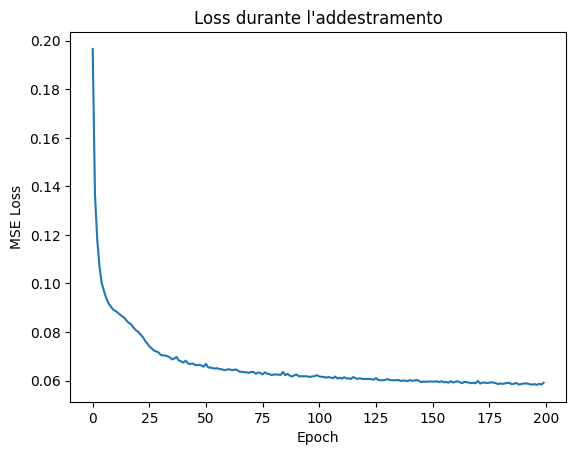


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [10]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=16, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)

#### Relu

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2317
Epoch 2/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1464
Epoch 3/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1271
Epoch 4/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1153
Epoch 5/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1074
Epoch 6/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1020
Epoch 7/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0976
Epoch 8/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0944
Epoch 9/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0912
Epoch 10/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0884
Epoch 11/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0857
Epoch 12/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0830
Epoch 13/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0806
Epoch 14/100
213/213 ━━━━━━━━

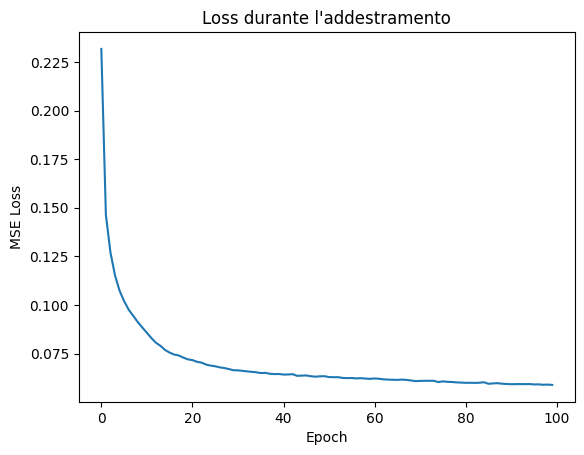


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [11]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)

#### Testing Autonecoder

##### Similarity Function

In [12]:
def trova_simili_ae(nome_giocatore, stagione_giocatore, df_latente, top_n=5, max_age=None, season_filter=None, same_role=False):
    # Cerchiamo l'indice del giocatore per nome e stagione
    mask_target = (
        (df_latente['player'].str.lower() == nome_giocatore.lower())
        & (df_latente['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente[mask_target].index
    
    if len(giocatore_idx) == 0:
        return "Giocatore non trovato nel database."
    
    idx = giocatore_idx[0]
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    stagione = df_latente.loc[idx, 'season']
    ruolo = df_latente.loc[idx, 'pos']
    
    print(f"\n[AUTOENCODER] Ricerca cloni per: {giocatore_reale} ({squadra_reale} - {stagione})")
    
    # Estraiamo i 10 numeri del giocatore cercato
    giocatore_vettore = df_latente.loc[idx, colonne_ae].values.reshape(1, -1)
    # Estraiamo i 10 numeri di TUTTI i giocatori
    tutti_i_vettori = df_latente[colonne_ae].values
    
    # Calcoliamo la Similarità Coseno
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]
    
    # Assegniamo i punteggi
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita
    
    # Escludiamo il giocatore target dai risultati
    df_latente_temp = df_latente_temp.drop(index=idx)
    
    # Filtro opzionale per età
    if max_age is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['age'] <= max_age]
    
    # Filtro opzionale per stagione
    if season_filter is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['season'] == season_filter]
    
    # Filtro opzionale per ruolo
    if same_role:
        df_latente_temp = df_latente_temp[df_latente_temp['pos'] == ruolo]
    
    df_latente_temp = df_latente_temp[df_latente_temp['player'] != nome_giocatore]
    
    # Ordiniamo dal più simile al meno simile
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    
    # Formattiamo la colonna in percentuale per renderla leggibile
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'
    
    colonne_output = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return simili[colonne_output]

##### Testing

In [21]:
# ==========================================
# 5. TESTIAMO IL MODELLO
# ==========================================
target_player = "Alessandro Bastoni"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'ReLU + Tanh bottleneck': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    #'Mix ReLU': df_latent_ae_mix_relu,
    'Mix Tanh': df_latent_ae_mix_tanh,
    'Mix Tanh Deeper': df_latent_ae_mix_tanh_deeper
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Modello: {model_name} =====")
    risultati_ae = trova_simili_ae(
        nome_giocatore=target_player,
        stagione_giocatore=target_season,
        df_latente=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_role=True
    )
    display(risultati_ae)


===== Modello: ReLU + Tanh bottleneck =====

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1366,Kyle Walker,33,Manchester City,DF,ENG-Premier League,2023 - 2024,86.7%
1537,Daley Blind,33,Girona,DF,ESP-La Liga,2023 - 2024,85.9%
2612,Jules Koundé,23,Barcelona,DF,ESP-La Liga,2022 - 2023,85.4%
356,Daley Blind,34,Girona,DF,ESP-La Liga,2024 - 2025,84.6%
2469,Andrew Robertson,28,Liverpool,DF,ENG-Premier League,2022 - 2023,84.2%



===== Modello: Tanh =====

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1537,Daley Blind,33,Girona,DF,ESP-La Liga,2023 - 2024,93.1%
356,Daley Blind,34,Girona,DF,ESP-La Liga,2024 - 2025,92.9%
2329,Ricardo Rodríguez,30,Torino,DF,ITA-Serie A,2023 - 2024,91.2%
2035,Hiroki Ito,24,Stuttgart,DF,GER-Bundesliga,2023 - 2024,90.8%
2612,Jules Koundé,23,Barcelona,DF,ESP-La Liga,2022 - 2023,90.7%



===== Modello: Mix Tanh =====

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1537,Daley Blind,33,Girona,DF,ESP-La Liga,2023 - 2024,86.5%
356,Daley Blind,34,Girona,DF,ESP-La Liga,2024 - 2025,86.1%
2329,Ricardo Rodríguez,30,Torino,DF,ITA-Serie A,2023 - 2024,85.5%
300,Iñigo Martínez,33,Barcelona,DF,ESP-La Liga,2024 - 2025,85.2%
2035,Hiroki Ito,24,Stuttgart,DF,GER-Bundesliga,2023 - 2024,84.7%



===== Modello: Mix Tanh Deeper =====

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1537,Daley Blind,33,Girona,DF,ESP-La Liga,2023 - 2024,90.6%
2035,Hiroki Ito,24,Stuttgart,DF,GER-Bundesliga,2023 - 2024,86.7%
1366,Kyle Walker,33,Manchester City,DF,ENG-Premier League,2023 - 2024,84.4%
825,Piero Hincapié,22,Leverkusen,DF,GER-Bundesliga,2024 - 2025,80.3%
1485,Mario Hermoso,28,Atlético Madrid,DF,ESP-La Liga,2023 - 2024,80.2%


In [23]:
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Nicolò Barella", "Federico Chiesa", "Riccardo Orsolini"]

for giocatore in target:
    for model_name, model_df in models_to_test.items():
        print(f"\n===== Modello: {model_name} =====")
        risultati_ae = trova_simili_ae(
            nome_giocatore=giocatore,
            stagione_giocatore=target_season,
            df_latente=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_role=True
        )
        display(risultati_ae)


===== Modello: ReLU + Tanh bottleneck =====

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)


,player,age,team,pos,league,season,Match %
460,Alex Baena,23,Villarreal,"MF,FW",ESP-La Liga,2024 - 2025,83.6%
1916,Fares Chaïbi,20,Eint Frankfurt,"MF,FW",GER-Bundesliga,2023 - 2024,78.5%
1795,Marco Asensio,27,Paris S-G,"MF,FW",FRA-Ligue 1,2023 - 2024,78.0%
2847,Rayan Cherki,18,Lyon,"MF,FW",FRA-Ligue 1,2022 - 2023,77.1%
520,Angelo Fulgini,27,Lens,"MF,FW",FRA-Ligue 1,2024 - 2025,76.1%



===== Modello: Tanh =====

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1916,Fares Chaïbi,20,Eint Frankfurt,"MF,FW",GER-Bundesliga,2023 - 2024,79.0%
410,Arda Güler,19,Real Madrid,"MF,FW",ESP-La Liga,2024 - 2025,78.3%
460,Alex Baena,23,Villarreal,"MF,FW",ESP-La Liga,2024 - 2025,75.7%
1334,Harvey Elliott,20,Liverpool,"MF,FW",ENG-Premier League,2023 - 2024,75.5%
520,Angelo Fulgini,27,Lens,"MF,FW",FRA-Ligue 1,2024 - 2025,75.4%



===== Modello: Mix Tanh =====

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)


...

,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,92.1%
1572,Ante Budimir,32,Osasuna,FW,ESP-La Liga,2023 - 2024,83.5%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,82.1%
355,Cristhian Stuani,37,Girona,FW,ESP-La Liga,2024 - 2025,82.1%
2285,Victor Osimhen,24,Napoli,FW,ITA-Serie A,2023 - 2024,81.6%



===== Modello: Mix Tanh =====

[AUTOENCODER] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,83.9%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,81.9%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,78.6%
2835,Terem Moffi,23,Lorient,FW,FRA-Ligue 1,2022 - 2023,78.3%
2312,Domenico Berardi,28,Sassuolo,FW,ITA-Serie A,2023 - 2024,75.3%



===== Modello: Mix Tanh Deeper =====

[AUTOENCODER] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,86.4%
3153,Niclas Füllkrug,29,Werder Bremen,FW,GER-Bundesliga,2022 - 2023,83.7%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,83.5%
287,Julián Álvarez,24,Atlético Madrid,FW,ESP-La Liga,2024 - 2025,83.4%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,81.0%


In [26]:
# Tabella unica con tutti i risultati (giocatore target x modello)
all_results = []

for giocatore in target:
    for model_name, model_df in models_to_test.items():
        res = trova_simili_ae(
            nome_giocatore=giocatore,          # fix: usa il giocatore del loop
            stagione_giocatore=target_season,
            df_latente=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_role=True
        )
        
        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = giocatore
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

# DataFrame finale "grouped"
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Ordine colonne per leggibilità
grouped_results_table = grouped_results_table[
    ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
].sort_values(["target_player", "model_used", "rank"])

display(grouped_results_table)


[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Nicolò Barella (Inter - 2024 - 202

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
30,Alessandro Bastoni,2024 - 2025,Mix Tanh,1,Daley Blind,33,Girona,DF,ESP-La Liga,2023 - 2024,86.5%
31,Alessandro Bastoni,2024 - 2025,Mix Tanh,2,Daley Blind,34,Girona,DF,ESP-La Liga,2024 - 2025,86.1%
32,Alessandro Bastoni,2024 - 2025,Mix Tanh,3,Ricardo Rodríguez,30,Torino,DF,ITA-Serie A,2023 - 2024,85.5%
33,Alessandro Bastoni,2024 - 2025,Mix Tanh,4,Iñigo Martínez,33,Barcelona,DF,ESP-La Liga,2024 - 2025,85.2%
34,Alessandro Bastoni,2024 - 2025,Mix Tanh,5,Hiroki Ito,24,Stuttgart,DF,GER-Bundesliga,2023 - 2024,84.7%
...,...,...,...,...,...,...,...,...,...,...,...
85,Riccardo Orsolini,2024 - 2025,Tanh,1,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,92.1%
86,Riccardo Orsolini,2024 - 2025,Tanh,2,Ante Budimir,32,Osasuna,FW,ESP-La Liga,2023 - 2024,83.5%
87,Riccardo Orsolini,2024 - 2025,Tanh,3,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,82.1%
88,Riccardo Orsolini,2024 - 2025,Tanh,4,Cristhian Stuani,37,Girona,FW,ESP-La Liga,2024 - 2025,82.1%


## Anomaly Detection

### SVM

### Autoencoder Reconstruction Error

## End

In [16]:
end_time = time.time()


In [18]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTempo totale di esecuzione: {elapsed_minutes:.0f}.{remaining_seconds:.0f}  min ")


Tempo totale di esecuzione: 18.32  min 
